# OSM vs ENTSO-E GridKit

This notebook compares some basic statistics of the PyPSA-EUR (ENTSO-E GridKit), PyPSA-Earth (OpenStreetMap) and public ENTSO-E statistics (latest/2022).

## Part I: Setup

### Libraries

In [2]:
# loading required libraries
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy import crs as ccrs
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import plot, iplot, init_notebook_mode
init_notebook_mode(connected=True)
import os

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

if not os.path.exists("output"):
    os.makedirs("output")

### PyPSA networks and data

In [3]:
network_pypsa_eur = pypsa.Network("networks/entsoe_europe/base.nc")
network_pypsa_earth = pypsa.Network("networks/osm_europe/base.nc")

print(network_pypsa_eur)
print(network_pypsa_earth)

INFO:pypsa.io:Imported network base.nc has buses, carriers, lines, links, transformers
INFO:pypsa.io:Imported network base.nc has buses, lines, links, transformers


PyPSA Network 'PyPSA-Eur'
Components:
 - Bus: 5664
 - Carrier: 2
 - Line: 7059
 - Link: 72
 - Transformer: 673
Snapshots: 8760
PyPSA Network 'PyPSA-Earth'
Components:
 - Bus: 6875
 - Line: 8385
 - Link: 252
 - Transformer: 1090
Snapshots: 8760


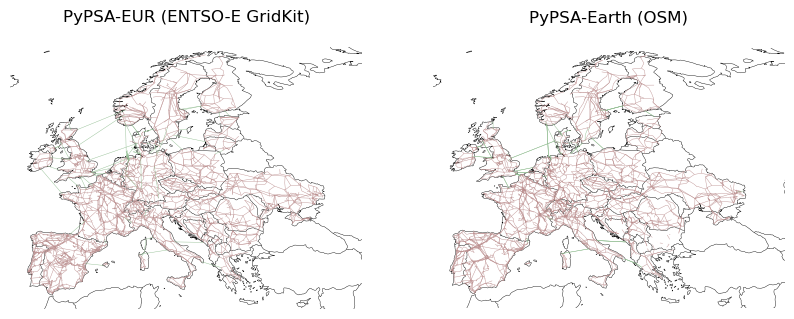

In [4]:
# Quick plots of the networks
fig, axes = plt.subplots(1, 2, figsize = (10, 5), subplot_kw = {"projection": ccrs.EqualEarth()})

network_pypsa_eur.plot(ax = axes[0], title = "PyPSA-EUR (ENTSO-E GridKit)\n", bus_sizes = 0, line_widths = 0.3, link_widths = 0.3)
network_pypsa_earth.plot(ax = axes[1], title = "PyPSA-Earth (OSM)\n", bus_sizes = 0, line_widths = 0.3, link_widths = 0.3)

# Show the plot
plt.show()

In [5]:
url_entsoe_stats = "data/inventory_of_transmission_2022.csv"
url_entsoe_stats = "https://www.entsoe.eu/publications/data/power-stats/2022/inventory_of_transmission_2022.csv"

df_entsoe_stats_raw = pd.read_csv(url_entsoe_stats, sep = ";", encoding='ISO-8859-1')

For comparing the overall AC high-voltage line lengths per country, we only look at ACL and ACC including and above 220 kV. We filter the data accordingly.

In [6]:
df_entsoe_stats_raw["Category"].unique()

array(['ACL_110kV_220kV', 'ACL_220kV', 'ACL_275kV', 'ACL_330kV',
       'ACL_380_400kV', 'ACL_750kV', 'ACC_220kV_380kV', 'ACC_Over_380kV',
       'DCC_220kV_380kV', 'DCC_Over_380kV', 'Of_PU_>400kV',
       'Of_PU_>330kV', 'Of_PU_>275kV', 'Of_PU_>220kV',
       'Nw_750kV_400kV_lower', 'Nw_400kV_330kV', 'Nw_400kV_220kV',
       'Nw_400kV_110kV_lower', 'Nw_330kV_220kV', 'Nw_330kV_110kV_lower',
       'Nw_275kV_110kV_lower', 'Nw_220kV_110kV_lower', 'DCC_110kV_220V',
       'Comments_1', 'Comments_2', 'Comments_3', 'Comments_4'],
      dtype=object)

In [7]:
# Relevant categories:
list_category = ["ACC_220kV_380kV", "ACC_Over_380kV", "ACL_220kV", "ACL_275kV", "ACL_330kV", "ACL_380_400kV", "ACL_750kV"]

In [8]:
df_entsoe_stats = df_entsoe_stats_raw.copy()
df_entsoe_stats = df_entsoe_stats[df_entsoe_stats["Category"].isin(list_category)]
df_entsoe_stats.head()

,MeasureItem,MeasureItemCategoryID,MeasureItemID,Category,Country,Year,LengthOfCircuits,LengthOfRoutes,NumberOfUnits,ProvidedValue,CreationDate,ProvidedValueCode
1,Inventory of Transmission,5,401,ACL_220kV,AT,2022,3735.0,1911.0,NaN,NaN,08/06/2023,NaN
2,Inventory of Transmission,5,402,ACL_275kV,AT,2022,NaN,NaN,NaN,NaN,08/06/2023,Not Expected
3,Inventory of Transmission,5,403,ACL_330kV,AT,2022,NaN,NaN,NaN,NaN,08/06/2023,Not Expected
4,Inventory of Transmission,5,404,ACL_380_400kV,AT,2022,3004.0,1386.0,NaN,NaN,08/06/2023,NaN
5,Inventory of Transmission,5,405,ACL_750kV,AT,2022,NaN,NaN,NaN,NaN,08/06/2023,Not Expected


### Aggregation per country

Now we group by countries and determine the sume of lengths in km.

In [9]:
df_entsoe_stats_grouped = df_entsoe_stats.groupby("Country") \
    .agg({"LengthOfCircuits": "sum", "LengthOfRoutes": "sum"})
df_entsoe_stats_grouped.rename(columns = {"LengthOfCircuits": "length_stats_circuits", "LengthOfRoutes": "length_stats_routes"}, inplace = True)
df_entsoe_stats_grouped.index.name = "country"
df_entsoe_stats_grouped.head()

,length_stats_circuits,length_stats_routes
country,,
AL,1695.700,1695.700
AT,6801.000,3358.000
BA,2386.020,0.000
BE,2184.742,1319.984
BG,5742.000,5742.000


Next we create dataframes for the lines of the respective PyPSA networks.

In [10]:
df_lines_entsoe = network_pypsa_eur.lines.merge(network_pypsa_eur.buses[["country"]], left_on = "bus0", right_index = True)
df_lines_entsoe = df_lines_entsoe.merge(network_pypsa_eur.buses[["country"]], left_on = "bus1", right_index = True, suffixes = ("0", "1"))

# We only keep the lines that are within the same country
df_lines_entsoe = df_lines_entsoe[df_lines_entsoe["country0"] == df_lines_entsoe["country1"]]

# Group by and sum the length of the lines
df_lines_entsoe_grouped = df_lines_entsoe.groupby("country0") \
    .agg({"length": "sum"})

# Rename index to "country"
df_lines_entsoe_grouped.index.name = "country"
df_lines_entsoe_grouped.head()

,length
country,
AL,1115.355063
AT,2823.123721
BA,1628.336830
BE,1206.390740
BG,3450.001920


In [11]:
df_lines_osm = network_pypsa_earth.lines.drop(columns = "country").merge(network_pypsa_earth.buses[["country"]], left_on = "bus0", right_index = True)
df_lines_osm = df_lines_osm.merge(network_pypsa_earth.buses[["country"]], left_on = "bus1", right_index = True, suffixes = ("0", "1"))

# We only keep the lines that are within the same country
df_lines_osm = df_lines_osm[df_lines_osm["country0"] == df_lines_osm["country1"]]
df_lines_osm

# Group by and sum the length of the lines
df_lines_osm_grouped = df_lines_osm.groupby("country0") \
    .agg({"length": "sum"})

# Rename index to "country"
df_lines_osm_grouped.index.name = "country"
df_lines_osm_grouped.head()

,length
country,
AL,1542.359388
AT,5492.722458
BA,180.179684
BE,1972.732502
BG,325.502993


Next we perform an outer merge on the dataframes.

In [12]:
df_lines_length = df_entsoe_stats_grouped.merge(df_lines_entsoe_grouped, on = "country", how = "outer")
df_lines_length = df_lines_length.merge(df_lines_osm_grouped, on = "country", how = "outer", suffixes = ("_pypsa_eur", "_pypsa_earth"))

# We drop NAs
df_lines_length.dropna(inplace = True)

df_lines_length

,length_stats_circuits,length_stats_routes,length_pypsa_eur,length_pypsa_earth
country,,,,
AL,1695.700000,1695.70000,1115.355063,1542.359388
AT,6801.000000,3358.00000,2823.123721,5492.722458
BA,2386.020000,0.00000,1628.336830,180.179684
BE,2184.742000,1319.98400,1206.390740,1972.732502
BG,5742.000000,5742.00000,3450.001920,325.502993
CH,6835.000000,0.00000,3408.513935,6337.680095
CZ,5764.000000,4474.00000,4147.269718,6418.090432
DE,33148.971000,19293.72670,17361.571117,29906.183995
DK,2248.790000,1542.14000,1517.464857,2077.047260


### Visualisation

In [13]:
fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles = ("PyPSA-Earth (OSM) length <br>vs. ENTSO-E Stats circuit length<br>", 
                      "PyPSA-EUR (ENTSO-E GridKit) length <br>vs. ENTSO-E Stats (single) route length"))

fig.add_trace(
    go.Scatter(
        x=df_lines_length["length_stats_circuits"],
        y=df_lines_length["length_pypsa_earth"],
        mode="markers",
        marker=dict(color="blue", opacity=0.2),
        name="Line length (km)",
    ),
    row=1, col=1
)

fig.add_trace(  
    go.Scatter(
        x=df_lines_length["length_stats_routes"], 
        y=df_lines_length["length_pypsa_eur"],
        mode="markers",
        marker=dict(color="green", opacity=0.2),
        name="Line length (km)"
    ),
    row=1, col=2
)

fig.add_trace(
    go.Scatter(
        x = [0, max(df_lines_length["length_stats_circuits"].max(), 
                    df_lines_length["length_pypsa_earth"].max())],
        y = [0, max(df_lines_length["length_stats_circuits"].max(), 
                    df_lines_length["length_pypsa_earth"].max())],
        mode = "lines",
        line = dict(color = "black", width = 1),
        showlegend = False
        ),
    row = 1, col = 1
    )

fig.add_trace(
    go.Scatter(
        x = [0, max(df_lines_length["length_stats_routes"].max(), 
                    df_lines_length["length_pypsa_eur"].max())],
        y = [0, max(df_lines_length["length_stats_routes"].max(), 
                    df_lines_length["length_pypsa_eur"].max())],
        mode = "lines",
        line = dict(color = "black", width = 1),
        showlegend = False
        ),
    row = 1, col = 2
    )

fig.update_traces(
    hovertemplate = "<b>Region</b>: %{text}<br><b>ENTSO-E Stats</b>: %{x} km<br><b>PyPSA</b>: %{y} km",
    text = df_lines_length.index
    )

fig["layout"]["xaxis"]["title"]="ENTSO-E Stats circuit length [km]"
fig["layout"]["yaxis"]["title"]="PyPSA-Earth (OSM) length [km]"

fig["layout"]["xaxis2"]["title"]="ENTSO-E Stats (single) route length [km]"
fig["layout"]["yaxis2"]["title"]="PyPSA-EUR (ENTSO-E GridKit) length [km]"

# keep x and y ratio the same
fig.update_xaxes(scaleanchor = "y", scaleratio = 1, row = 1, col = 1)
fig.update_yaxes(scaleanchor = "x", scaleratio = 1, row = 1, col = 1)

# make both subplots square 
fig.update_layout(width = 1000, height = 500)

fig.write_html("output/scatterplot_compare_lengths.html")
fig.show()


In [14]:
# Bar chart of the length of the lines in the networks and the statistics for each country on the x-axis
# All four length columns on the y-axis
# Using plotly

fig = px.bar(df_lines_length, x = df_lines_length.index, y = ["length_stats_circuits", "length_pypsa_earth", "length_stats_routes", "length_pypsa_eur"],
                title = "Length of lines in the networks and statistics for each country",
                labels = {"value": "Length [km]", "variable": "Length"},
                barmode = "group")

# make both subplots square 
fig.update_layout(width = 2000, height = 500)

fig.write_html("output/barchart_compare_lengths.html")
fig.show()
